In [270]:
import pandas as pd
import matplotlib.pyplot as plt

In [271]:
import sys
print(sys.executable)

c:\Users\lujim\miniconda3\envs\cmapss\python.exe


In [272]:
cols = ['unit', 'cycle'] \
     + [f'op_setting_{i}' for i in range(1, 4)] \
     + [f'sensor_{i}' for i in range(1, 22)]

df = pd.read_csv('../data/CMaps/train_FD001.txt',
                 sep=r'\s+', header=None, names=cols)

df.head()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [273]:
lifespans = df.groupby('unit')['cycle'].max()
lifespans

unit
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: cycle, Length: 100, dtype: int64

In [274]:
df.groupby('unit')['cycle'].max()

unit
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: cycle, Length: 100, dtype: int64

In [275]:
df[df['unit'] == 1].tail()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,519.79,2388.23,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,519.58,2388.33,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,520.04,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,519.57,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295
191,1,192,0.0009,-0.0000,100.0,518.67,643.54,1601.41,1427.20,14.62,...,520.08,2388.32,8110.93,8.5113,0.03,396,2388,100.0,38.48,22.9649


In [276]:
lifespans.min()
lifespans.max()



np.int64(362)

In [277]:
lifespans.min()
lifespans.max()

np.int64(362)

In [278]:
print(lifespans.min())
print(lifespans.max())

128
362


In [279]:
lifespans

unit
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: cycle, Length: 100, dtype: int64

同一型号的发动机,寿命差了近三倍;如果按固定周期维护,定在 128 就对长寿发动机过度维修浪费钱,定得晚就让短命发动机带病上天。所以需要按每台发动机的实际状态预测寿命。

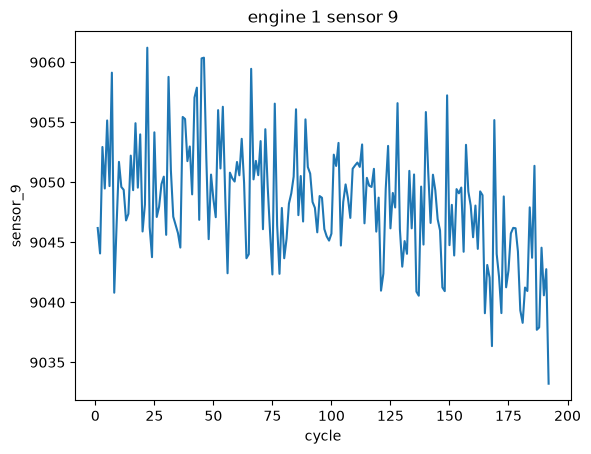

In [280]:
engine1 = df[df['unit'] == 1] 
plt.plot(engine1['cycle'], engine1['sensor_9'])  
plt.xlabel('cycle')   
plt.ylabel('sensor_9')        
plt.title('engine 1 sensor 9')    
plt.show()              

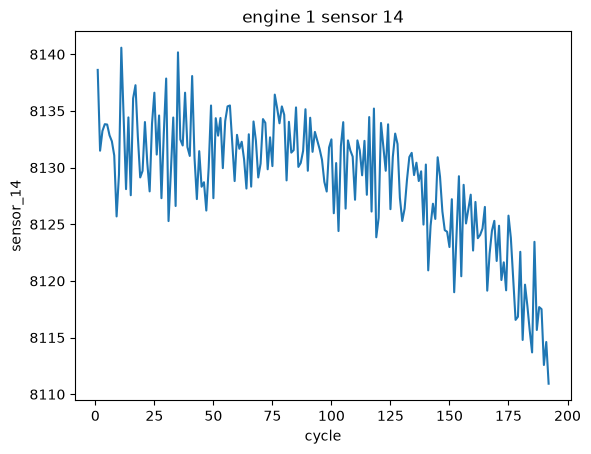

In [281]:
engine1 = df[df['unit'] == 1]     
plt.plot(engine1['cycle'], engine1['sensor_14']) 
plt.xlabel('cycle')       
plt.ylabel('sensor_14')      
plt.title('engine 1 sensor 14')      
plt.show()          

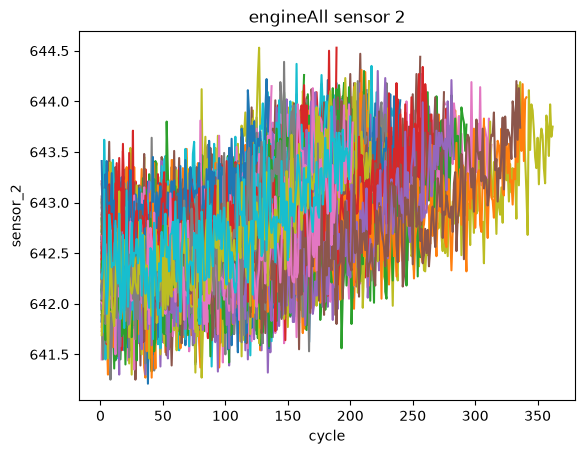

In [282]:
for i in lifespans.index:
    engineAll = df[df['unit'] == i]    
    plt.plot(engineAll['cycle'], engineAll['sensor_2'])
plt.xlabel('cycle')
plt.ylabel('sensor_2')
plt.title('engineAll sensor 2')
plt.show()

In [283]:
df.describe()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [284]:
sensor_cols = cols[5:]           

early = df.groupby('unit').head(10)[sensor_cols].mean()
late  = df.groupby('unit').tail(10)[sensor_cols].mean()

trend = late - early
trend
up = trend[trend > 0]
down = trend [ trend <0 ]
nochange = trend [trend == 0]

print (up)
print (down )
print(nochange)


sensor_2      1.223570
sensor_3     14.636730
sensor_4     24.748790
sensor_6      0.000510
sensor_8      0.162460
sensor_9     39.548600
sensor_11     0.749210
sensor_13     0.166060
sensor_14    27.834780
sensor_15     0.097058
sensor_17     3.789000
dtype: float64
sensor_7    -2.330440
sensor_12   -1.991140
sensor_20   -0.464410
sensor_21   -0.278384
dtype: float64
sensor_1     0.0
sensor_5     0.0
sensor_10    0.0
sensor_16    0.0
sensor_18    0.0
sensor_19    0.0
dtype: float64


退化是双向的。11 个往上走(温度、压力类——机器带病运转,内部越来越热),4 个往下走(sensor_7、12 这些效率相关的量——性能衰减)。这符合物理直觉:发动机老化 = 热的更热、效的更低

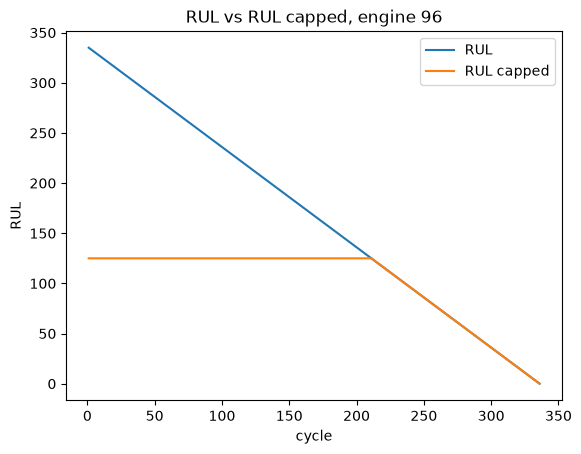

In [285]:
df['RUL']=df.groupby('unit')['cycle'].transform('max') - df['cycle']
df['RUL-capped']= df['RUL'].clip(upper=125)
engine96 = df[df['unit'] == 96]
plt.plot(engine96['cycle'], engine96['RUL'], label='RUL')
plt.plot(engine96['cycle'], engine96['RUL-capped'], label='RUL capped')
plt.xlabel('cycle')
plt.ylabel('RUL')
plt.title('RUL vs RUL capped, engine 96')
plt.legend()
plt.show()

公式:RUL = L − c(L = 该发动机总寿命,即 cycle 最大值;c = 当前循环)。实现:groupby('unit')['cycle'].transform('max') 把每台的 L 对齐到流水账每一行
封顶(cap=125)的理由: 发动机生命前期传感器读数极为相近(见 100 台叠加图左半段),模型无法从中分辨剩余寿命是 276 还是 325——这些信息传感器里根本没有。封顶后,我们把任务从"猜准确大数"改写为"健康期统一回答 125,退化显形后才精确倒计时",这才是数据支撑得起的合理任务。见 engine 96 的平台-斜坡对比图。

In [286]:
cols2 = ['unit', 'cycle'] \
     + [f'op_setting_{i}' for i in range(1, 4)] \
     + [f'sensor_{i}' for i in range(1, 22)]

test_df = pd.read_csv('../data/CMaps/test_FD001.txt',
                 sep=r'\s+', header=None, names=cols)

test_df.head()
test_lifespans = test_df.groupby('unit')['cycle'].max()
print (test_lifespans)

unit
1       31
2       49
3      126
4      106
5       98
      ... 
96      97
97     134
98     121
99      97
100    198
Name: cycle, Length: 100, dtype: int64


In [287]:
cols3 = ['unit', 'cycle'] \
     + [f'op_setting_{i}' for i in range(1, 4)] \
     + [f'sensor_{i}' for i in range(1, 22)]

RUL_df = pd.read_csv('../data/CMaps/RUL_FD001.txt',
                     names=['true_RUL'] )

RUL_df.head()

,true_RUL
0,112
1,98
2,69
3,82
4,91


In [288]:
sensor_cols = cols[5:]           

early = df.groupby('unit').head(10)[sensor_cols].mean()
late  = df.groupby('unit').tail(10)[sensor_cols].mean()

trend = late - early
up = trend[trend > 0]
down = trend [ trend <0 ]
nochange = trend [trend == 0]

dead = list(nochange.index)
features = [s for s in sensor_cols if s not in dead]
print(features)
print(len(features))

['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
15


cycle行列的本质是用RUL公式让模型拥有一条快速计算的方法，可在真正的数据集里面是没有这种公式的，senor6的变化虽然极小，但仍处于变化，

In [289]:
X = df[features]
y = df['RUL-capped']
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](15,)","[-4.57,-0.28,-0.46,...,-1.29,13.81,22.5 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](15,)","['sensor_2','sensor_3','sensor_4',...,'sensor_17','sensor_20','sensor_21']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.247e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,15


In [290]:
train_pred = model.predict(X)
print(train_pred[:10])
print(y[:10].values) 

[121.32934465 118.92855654 125.59569994 136.20213992 118.069484
 131.69843197 125.8815123  130.89908122 130.21950618 126.1582829 ]
[125 125 125 125 125 125 125 125 125 125]


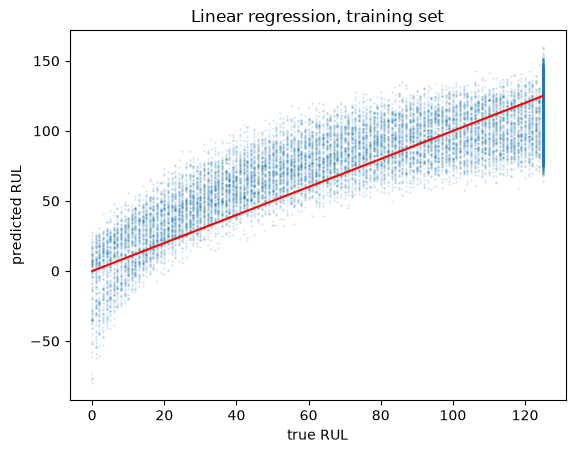

In [291]:
plt.scatter(y, train_pred, alpha=0.1, s=1)
plt.plot([0, 125], [0, 125], color='red')   # y=x 参考线:落在线上=猜得全对
plt.xlabel('true RUL')
plt.ylabel('predicted RUL')
plt.title('Linear regression, training set')
plt.show()

In [292]:
last_rows = test_df.groupby('unit').tail(1)[sensor_cols]
x_test = last_rows[features]
test_pred = model.predict(x_test)
print(test_pred[:10])
print(RUL_df['true_RUL'][:10].values)

[120.96760148  98.84634462  73.02843828  80.98127275  90.03910694
  95.8575834  102.84305385  79.79112112  90.42856139  93.69725222]
[112  98  69  82  91  93  91  95 111  96]


In [293]:
import numpy as np

errors = test_pred - RUL_df['true_RUL'].values
rmse = np.sqrt((errors ** 2).mean())
print(rmse)

21.894735146498967


In [294]:
from sklearn.metrics import root_mean_squared_error
print(root_mean_squared_error(RUL_df['true_RUL'], test_pred))

21.894735146498967


| 模型 | 特征 | RMSE |
|---|---|---|
| LinearRegression | 15 sensors, cap=125 | 21.89 |

In [295]:
x_test.columns

Index(['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8',
       'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14',
       'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21'],
      dtype='str')

In [296]:
import pandas as pd
weights = pd.Series(model.coef_, index=features).sort_values()
print(weights)

sensor_15    -87.941427
sensor_11    -22.537520
sensor_13    -19.349846
sensor_8     -16.104329
sensor_2      -4.567525
sensor_17     -1.291807
sensor_4      -0.463023
sensor_3      -0.280883
sensor_9      -0.275703
sensor_14     -0.223718
sensor_7       4.697731
sensor_12      7.204439
sensor_20     13.806016
sensor_21     22.501388
sensor_6     719.291984
dtype: float64


sensor 9 和 14 的权重 接近零是因为多重共线性，当信息重叠时，线性回归会把大多数影响随机分给其中几个不同的传感器。sensor6的极度异常的权重是因为它的波动很小，才达到0.0005，所以为了让他的变化在加权里更明显所以给他配给了超大的权重，真实贡献等于权重相乘传感器波动。

In [297]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)          
X_test_scaled = scaler.transform(x_test)    
model2= LinearRegression()
model2.fit(X_scaled, y)
pred2=model2.predict(X_test_scaled)
model2.coef_
import pandas as pd
weights = pd.Series(model2.coef_, index=features).sort_values()
print(weights)

sensor_9    -6.088165
sensor_11   -6.019342
sensor_14   -4.267579
sensor_4    -4.167382
sensor_15   -3.298167
sensor_2    -2.283950
sensor_17   -2.000654
sensor_3    -1.722095
sensor_13   -1.391586
sensor_8    -1.143146
sensor_6     0.999062
sensor_21    2.435736
sensor_20    2.495328
sensor_7     4.157825
sensor_12    5.313530
dtype: float64


In [298]:
import numpy as np

errors = pred2 - RUL_df['true_RUL'].values
rmse = np.sqrt((errors ** 2).mean())
print(rmse)

21.89473514649618


LinearRegression + scaler / 15 sensors / 21.89(不变,权重可读)

In [299]:
print('features:', features)
print('len:', len(features))
print('dead:', dead)
print('sensor_cols:', len(sensor_cols))

features: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
len: 15
dead: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
sensor_cols: 21


In [300]:
for s in features:
    df[s + '_rmean'] = df.groupby('unit')[s].rolling(window=20,min_periods=1).mean().reset_index(level=0, drop=True)
    df[s + '_rstd']  = df.groupby('unit')[s].rolling(window=20,min_periods=1).std().reset_index(level=0, drop=True)
df=df.fillna(0)

In [301]:
for s in features:
    test_df[s + '_rmean'] = test_df.groupby('unit')[s].rolling(window=20,min_periods=1).mean().reset_index(level=0, drop=True)
    test_df[s + '_rstd']  = test_df.groupby('unit')[s].rolling(window=20,min_periods=1).std().reset_index(level=0, drop=True)
test_df=test_df.fillna(0)

In [302]:
print('探针A:', df.shape, 'sensor_2_rmean' in df.columns)

探针A: (20631, 58) True


In [303]:
print(test_df.shape)
print(test_df[['sensor_2','sensor_2_rmean']].head(25))
print(test_df.isna().sum().sum()) 


(13096, 56)
    sensor_2  sensor_2_rmean
0     643.02      643.020000
1     641.71      642.365000
2     642.46      642.396667
3     642.44      642.407500
4     642.51      642.428000
5     642.11      642.375000
6     642.11      642.337143
7     642.54      642.362500
8     641.88      642.308889
9     642.07      642.285000
10    642.04      642.262727
11    642.54      642.285833
12    641.94      642.259231
13    642.23      642.257143
14    642.50      642.273333
15    642.32      642.276250
16    642.19      642.271176
17    642.59      642.288889
18    642.43      642.296316
19    642.61      642.312000
20    642.70      642.296000
21    642.45      642.333000
22    642.12      642.316000
23    642.32      642.310000
24    642.25      642.297000
0


In [304]:
print('探针B:', df.shape, 'sensor_2_rmean' in df.columns)

探针B: (20631, 58) True


In [305]:
X = df[features_v2]
y = df['RUL-capped']
x_test = test_df.groupby('unit').tail(1)[features_v2]
print(X.shape, len(y), x_test.shape)   # 必须 (20631,45) 20631 (100,45)

(20631, 45) 20631 (100, 45)


In [306]:
from sklearn.preprocessing import StandardScaler

features_v2 = features + [s+'_rmean' for s in features] + [s+'_rstd' for s in features]
print(len(features_v2)) 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)           # 训练集:fit + transform
x_test_scaled = scaler.transform(x_test)     # 考卷:只 transform
model3 = LinearRegression()
model3.fit(X_scaled, y)                      # 用训练集学
pred3 = model3.predict(x_test_scaled)        # 考新卷
model3.coef_
import pandas as pd
weights = pd.Series(model3.coef_, index=features_v2).sort_values()
print(weights)

45
sensor_14_rmean    -9.378393
sensor_11          -6.080319
sensor_15_rmean    -4.189814
sensor_8           -3.970522
sensor_4           -3.956847
sensor_4_rmean     -3.865314
sensor_13          -3.727881
sensor_6_rstd      -3.499707
sensor_15          -2.903357
sensor_2           -2.374776
sensor_2_rmean     -2.310378
sensor_17          -1.876385
sensor_13_rstd     -1.863279
sensor_3_rmean     -1.794829
sensor_3           -1.590797
sensor_17_rmean    -1.587331
sensor_9_rmean     -1.269897
sensor_12_rstd     -1.145607
sensor_8_rstd      -1.056336
sensor_11_rstd     -1.022745
sensor_11_rmean    -0.690455
sensor_7_rstd      -0.672797
sensor_4_rstd      -0.636140
sensor_15_rstd     -0.223864
sensor_3_rstd      -0.154329
sensor_20_rstd     -0.044402
sensor_6           -0.001565
sensor_17_rstd      0.055160
sensor_14_rstd      0.132653
sensor_6_rmean      0.201988
sensor_2_rstd       0.290109
sensor_9_rstd       0.425856
sensor_21_rmean     0.669882
sensor_21_rstd      0.688008
sensor_9   

In [307]:
print(X_scaled.shape)        # 应该 (20631, 45);若 (20631, 15),石锤
print(len(model3.coef_))     # 应该 45;若 15,石锤

(20631, 45)
45


In [308]:
import numpy as np

errors = pred3 - RUL_df['true_RUL'].values
rmse = np.sqrt((errors ** 2).mean())
print(rmse)

20.193932727651905


LinearRegression / 45 features (rolling) / 20.19

In [309]:
from sklearn.ensemble import RandomForestRegressor

model4 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model4.fit(X, y)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [310]:
pred4 = model4.predict(x_test)
errors = pred4 - RUL_df['true_RUL'].values


In [311]:
import numpy as np

errors = pred4 - RUL_df['true_RUL'].values
rmse = np.sqrt((errors ** 2).mean())
print(rmse)

22.014238301608348


In [312]:
print('train RMSE:', np.sqrt(((model4.predict(X) - y) ** 2).mean()))

train RMSE: 3.104758880473571


In [313]:
model5 = RandomForestRegressor(n_estimators=100, max_depth=8,
                               min_samples_leaf=20,
                               random_state=42, n_jobs=-1)

In [314]:
import numpy as np

errors = pred4 - RUL_df['true_RUL'].values
rmse = np.sqrt((errors ** 2).mean())
print(rmse)

22.014238301608348


In [315]:
model5.fit(X, y)
pred5 = model5.predict(x_test)
print('test :', np.sqrt(((pred5 - RUL_df['true_RUL'].values) ** 2).mean()))
print('train:', np.sqrt(((model5.predict(X) - y) ** 2).mean()))

test : 21.61964370219622
train: 14.784604764836919


In [316]:
imp = pd.Series(model5.feature_importances_, index=features_v2).sort_values(ascending=False)
print(imp.head(10))
print(imp.tail(10))


sensor_3_rmean     0.629525
sensor_2_rmean     0.113660
sensor_9_rmean     0.057721
sensor_9           0.035984
sensor_4_rmean     0.031932
sensor_21_rmean    0.025807
sensor_15_rmean    0.015221
sensor_14_rmean    0.011521
sensor_17_rmean    0.011094
sensor_20_rmean    0.009011
dtype: float64
sensor_4          0.000199
sensor_15         0.000118
sensor_6_rstd     0.000067
sensor_2          0.000050
sensor_6_rmean    0.000047
sensor_21         0.000042
sensor_20         0.000039
sensor_3          0.000011
sensor_17         0.000011
sensor_6          0.000000
dtype: float64
